# 11_Statistical_Tests

Hypothesis testing tells you whether to trust a result. This notebook covers the actual tests you reach for once you're there — t-test, z-test, chi-square, ANOVA, Mann-Whitney U, and Shapiro-Wilk.

## 01. T-Test

**Definition**: Compares the mean of one group against a value, or the means of two groups, when the population standard deviation is unknown and the sample isn't huge.

**Assumptions**: Data is roughly normal (matters more with small samples), observations are independent, and the two groups have similar variance — or you use Welch's version if they don't.

**When to use**: Comparing two group means, before/after comparisons, or a sample mean against a target value.

**When not to use**: 3+ groups (that's ANOVA), badly skewed data with a small sample (Mann-Whitney U is safer), or categorical data.

**Business Example**: An e-commerce team redesigns the checkout page and wants to know if average order value actually moved.

In [1]:
import numpy as np
from scipy import stats

old_design = np.array([58, 62, 60, 59, 61, 57, 63, 60, 58, 62])
new_design = np.array([65, 68, 64, 66, 69, 67, 65, 70, 66, 68])

t_stat, p_value = stats.ttest_ind(old_design, new_design, equal_var=False)

print(np.mean(old_design), np.mean(new_design))
print(t_stat, p_value)

60.0 66.8
-7.732600044504812 3.99477844316174e-07


**Interpretation**: p-value is way below 0.05, so the new design isn't just showing random noise — order value genuinely went up.

## 02. Z-Test

**Definition**: Same idea as the t-test but for large samples where the population variance is known or safely assumed. Comes up a lot in proportion testing — conversion rates, click-through rates, anything with a big enough n that the normal approximation holds.

**Assumptions**: Large sample (n ≥ 30 as a rule of thumb), known or reliably estimated variance, independent random sampling.

**When to use**: Comparing a sample rate to a known baseline, or two large samples against each other.

**When not to use**: Small samples (t-test), unknown variance with limited data, more than two groups.

**Business Example**: An app team rolls out a new onboarding flow and wants to check it against the historical 20% sign-up rate.

In [5]:
!pip install statsmodels



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from statsmodels.stats.proportion import proportions_ztest

new_flow_conversions = 620
new_flow_total = 2500
baseline_rate = 0.20

z_stat, p_value = proportions_ztest(count=new_flow_conversions, nobs=new_flow_total, value=baseline_rate)

print(new_flow_conversions / new_flow_total)
print(z_stat, p_value)

0.248
5.557461733534294 2.7372596854384234e-08


**Interpretation**: 24.8% vs a 20% baseline, and the p-value backs it up — this isn't luck, the new flow converts better.

## 03. Chi-Square Test

**Definition**: For categorical data. Tests whether two categorical variables are related (test of independence) or whether observed counts match what you'd expect (goodness of fit).

**Assumptions**: Counts, not raw measurements; independent observations; expected count in each cell should be at least ~5.

**When to use**: Association between categories — acquisition channel vs repeat purchase, region vs product preference, that kind of thing.

**When not to use**: Continuous data, tiny expected cell counts (use Fisher's Exact Test instead), non-independent samples.

**Business Example**: A retailer wants to know if the channel a customer came from (email, social, referral) has anything to do with whether they buy again.

In [7]:
import numpy as np
from scipy.stats import chi2_contingency

observed = np.array([
    [120, 80],
    [90, 110],
    [140, 60]
])

chi2_stat, p_value, dof, expected = chi2_contingency(observed)
print(chi2_stat, p_value, dof)

26.057142857142857 2.1966624261079916e-06 2


**Interpretation**: p-value is tiny, so channel and repeat-purchase behavior aren't independent — referral customers come back noticeably more than social media ones.

## 04. ANOVA

**Definition**: Once you're past two groups, ANOVA checks whether at least one group mean stands out from the rest. It doesn't tell you which one — that's a job for a follow-up post-hoc test like Tukey's HSD.

**Assumptions**: Continuous outcome, independent groups, roughly normal within each group, similar variances across groups.

**When to use**: Comparing 3+ groups at once — pricing tiers, store regions, treatment arms.

**When not to use**: Just two groups (t-test is simpler), badly violated normality/variance assumptions (try Kruskal-Wallis), repeated measures on the same subjects.

**Business Example**: A company runs three pricing strategies across stores and wants to know if revenue actually differs by strategy.

In [8]:
import numpy as np
from scipy import stats

low_price = np.array([42, 45, 40, 44, 43, 41, 46])
medium_price = np.array([50, 52, 48, 51, 53, 49, 50])
premium_price = np.array([47, 46, 49, 48, 45, 50, 47])

f_stat, p_value = stats.f_oneway(low_price, medium_price, premium_price)
print(f_stat, p_value)

27.743243243243217 3.173841205677792e-06


**Interpretation**: Significant result — at least one pricing tier pulls away from the others. Medium has the highest average here, so that's where a post-hoc test would look next.

## 05. Mann-Whitney U Test

**Definition**: The non-parametric cousin of the t-test. Instead of comparing means directly, it ranks the data and compares those ranks — so it doesn't care about normality and shrugs off outliers.

**Assumptions**: Independent samples, data can at least be ranked, no normality requirement, ideally similar-shaped distributions so it reads as a median comparison.

**When to use**: Two groups where data is skewed, has outliers, or is ordinal.

**When not to use**: Normal data with a decent sample size (t-test has more power there), 3+ groups (Kruskal-Wallis), purely nominal data with no order (Chi-Square).

**Business Example**: A streaming service compares session length across two app versions, but the data is skewed with a few very long outlier sessions.

In [9]:
import numpy as np
from scipy import stats

app_version_a = np.array([12, 15, 14, 13, 60, 16, 14, 13, 15, 12])
app_version_b = np.array([18, 20, 19, 21, 85, 19, 20, 18, 22, 19])

u_stat, p_value = stats.mannwhitneyu(app_version_a, app_version_b, alternative='two-sided')
print(np.median(app_version_a), np.median(app_version_b))
print(u_stat, p_value)

14.0 19.5
9.0 0.002118567218014083


**Interpretation**: p-value under 0.05 — the two versions really do differ in session length, and since the data was messy, ranking it this way gives a more trustworthy answer than a plain t-test would.

## 06. Shapiro-Wilk Test

**Definition**: Checks whether a sample looks like it came from a normal distribution. Usually the first thing to run before committing to a t-test, ANOVA, or Pearson correlation, since those all lean on normality.

**Assumptions**: Continuous data, independent observations. Works best for small-to-moderate samples — with very large samples it flags trivial deviations as "significant."

**When to use**: Checking normality before a parametric test, checking regression residuals.

**When not to use**: Huge samples (over-sensitive), categorical/count data, as the only check — pair it with a Q-Q plot or histogram, and skip it entirely if a non-parametric test is already the plan.

**Business Example**: A manufacturing QC team wants to confirm product weights are normal before setting up control charts that assume normality.

In [10]:
import numpy as np
from scipy import stats

product_weights = np.array([498, 502, 500, 501, 499, 503, 497, 500, 502, 499,
                             501, 500, 498, 503, 500])

stat, p_value = stats.shapiro(product_weights)
print(stat, p_value)

0.9568103652744508 0.6371749311232175


**Interpretation**: p-value is well above 0.05, so nothing here rules out normality — the weights look consistent with a normal distribution and it's fine to move ahead with normality-based control charts.

## T-distribution vs Z-distribution

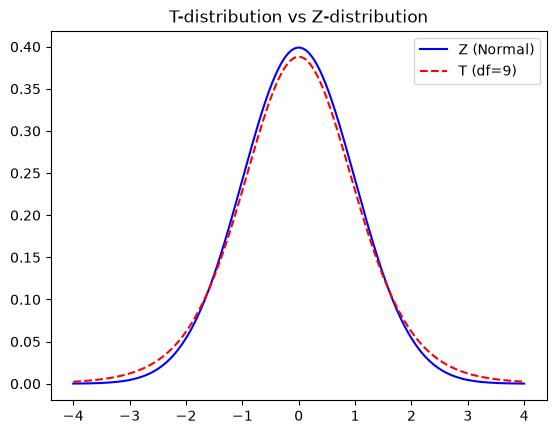

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-4, 4, 1000)
t_dist = stats.t.pdf(x, df=9)
z_dist = stats.norm.pdf(x, 0, 1)

plt.plot(x, z_dist, label='Z (Normal)', color='blue')
plt.plot(x, t_dist, label='T (df=9)', color='red', linestyle='dashed')
plt.title("T-distribution vs Z-distribution")
plt.legend()
plt.show()

**Interpretation**: The t-distribution has fatter tails — that's the extra uncertainty from estimating variance off a small sample. As n grows, it converges to the normal curve, which is basically why the z-test takes over at large sample sizes.

In [15]:
pip install -U matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Revenue by Pricing Strategy

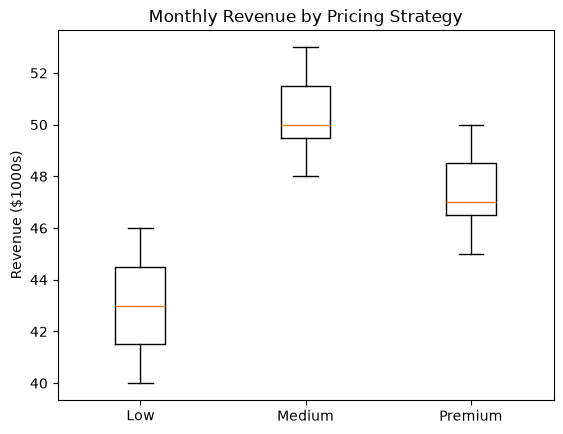

In [17]:
import matplotlib.pyplot as plt

low_price = [42, 45, 40, 44, 43, 41, 46]
medium_price = [50, 52, 48, 51, 53, 49, 50]
premium_price = [47, 46, 49, 48, 45, 50, 47]

plt.boxplot([low_price, medium_price, premium_price], tick_labels=['Low', 'Medium', 'Premium'])
plt.title("Monthly Revenue by Pricing Strategy")
plt.ylabel("Revenue ($1000s)")
plt.show()

**Interpretation**: Medium clearly sits above the other two here, which lines up with what the ANOVA result already told us.